In [1]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame

df = pd.read_csv('../../data/train.csv')
df

,id,LoanNr_ChkDgt,Name,City,State,Bank,BankState,ApprovalDate,ApprovalFY,NoEmp,...,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,DisbursementDate,DisbursementGross,BalanceGross,Accept
0,64afe857c28,9448323000,MIDWEST CRANKSHAFT & ENGINE,HARVEY,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,9-Aug-96,1996,28,...,0,0,1,0,N,N,31-Mar-97,"$600,000.00",$0.00,0
1,1705a7346c2,2854405007,"Iredesign, Limited",CHICAGO,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,10-Dec-07,2008,1,...,1,1,0,1,N,N,31-Dec-07,"$25,400.00",$0.00,1
2,7439801ad8a,9300423010,PHILLY'S INC.,ROCHELLE,IL,BMO HARRIS BK NATL ASSOC,IL,23-May-96,1996,6,...,0,0,1,0,N,Y,30-Sep-96,"$20,000.00",$0.00,1
3,a3f8f9d0611,4349265000,USA Laser Imaging Inc.,Loves park,IL,ALPINE BANK & TRUST CO.,IL,4-Nov-10,2011,5,...,0,5,0,1,N,N,1-Mar-11,"$75,000.00",$0.00,1
4,71e4f243b5d,2433905006,"Dan Morrell, Inc.",LISLE,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,3-May-07,2007,3,...,1,3,0,1,N,N,31-May-07,"$50,000.00",$0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20763,530b1abc4d5,5400325006,OMC Construction & Restoration,MORTON GROVE,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,7-Sep-12,2012,1,...,10,0,0,1,Y,N,7-Sep-12,"$45,000.00",$0.00,1
20764,d759e7e1aac,2242345001,Ronald J Wirth,ROMEOVILLE,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,26-Jan-07,2007,1,...,6,4,0,1,N,N,31-Jan-07,"$55,000.00",$0.00,1
20765,d902be78167,7805983010,CHICAGO GOURMET FOODS,ELMHURST,IL,FIFTH THIRD BANK,IL,16-Nov-94,1995,8,...,0,0,1,0,N,Y,31-Jan-95,"$100,000.00",$0.00,0
20766,76adcc08afc,8905864007,"ANNIE RIVER SOLUTIONS, INC",GLEN ELLYN,IL,U.S. BANK NATIONAL ASSOCIATION,OH,6-Jun-05,2005,1,...,1,2,1,1,Y,N,30-Jun-05,"$178,634.00",$0.00,1


Query: What is the ratio of Approved vs. Denied loans?
<br>If 90% are accepted, the bank is aggressive. If 50% are denied, the bank is very conservative

        count  ratio_%
Accept                
1       16019    77.13
0        4749    22.87


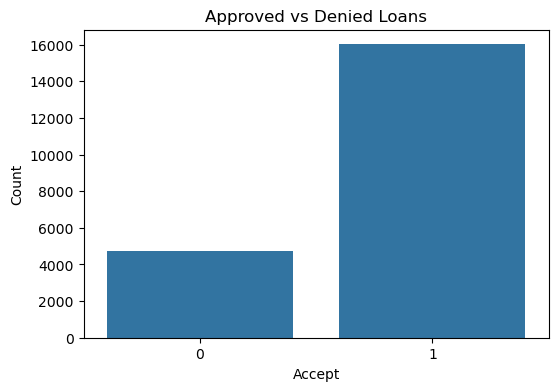

In [2]:
# What is the ratio of Approved vs. Denied loans?
import seaborn as sns
import matplotlib.pyplot as plt

counts = df['Accept'].value_counts(dropna=False)
ratios = df['Accept'].value_counts(normalize=True, dropna=False).mul(100).round(2)

summary = pd.DataFrame({'count': counts, 'ratio_%': ratios})
print(summary)

plt.figure(figsize=(6, 4))
sns.countplot(x='Accept', data=df)
plt.title('Approved vs Denied Loans')
plt.xlabel('Accept')
plt.ylabel('Count')
plt.show()

How does business maturity (NewExist) affect the outcome?
<br>Does being a "New Business" double the risk of denial? If so, Company X needs a higher score elsewhere to balance
     it out.

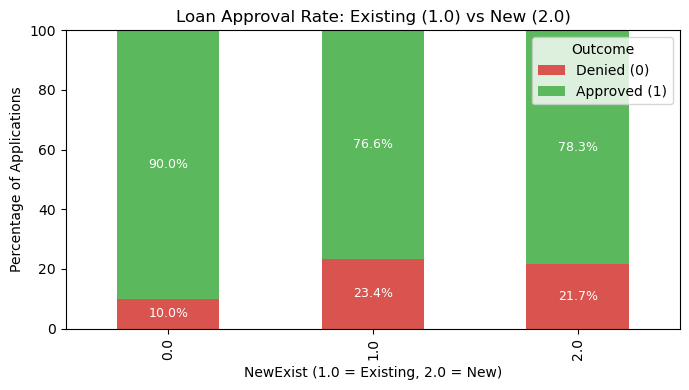

Accept,0,1
NewExist,,
0.0,10.000000,90.000000
1.0,23.416561,76.583439
2.0,21.712027,78.287973


In [3]:
# How does business maturity (NewExist) affect the outcome?
maturity_risk = (
    pd.crosstab(df['NewExist'], df['Accept'], normalize='index')
    .reindex(columns=[0, 1], fill_value=0)
    * 100
)

ax = maturity_risk.plot(
    kind='bar',
    stacked=True,
    color=['#d9534f', '#5cb85c'],
    figsize=(7, 4)
 )
ax.set_title('Loan Approval Rate: Existing (1.0) vs New (2.0)')
ax.set_xlabel('NewExist (1.0 = Existing, 2.0 = New)')
ax.set_ylabel('Percentage of Applications')
ax.set_ylim(0, 100)
ax.legend(['Denied (0)', 'Approved (1)'], title='Outcome', loc='upper right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', color='white', fontsize=9)

plt.tight_layout()
plt.show()

maturity_risk

In [6]:
# Quick check: what is NewExist = 0.0?
newexist_counts = df['NewExist'].value_counts(dropna=False).sort_index()
newexist_pct = (df['NewExist'].value_counts(dropna=False, normalize=True).sort_index() * 100).round(2)

newexist_summary = pd.DataFrame({
    'count': newexist_counts,
    'percentage_%': newexist_pct
})

print('NewExist value counts and percentages:')
display(newexist_summary)

print('\nNewExist vs Accept crosstab:')
display(pd.crosstab(df['NewExist'], df['Accept']))

NewExist value counts and percentages:


,count,percentage_%
NewExist,,
0.0,10,0.05
1.0,14178,68.27
2.0,6577,31.67
NaN,3,0.01



NewExist vs Accept crosstab:


Accept,0,1
NewExist,,
0.0,1,9
1.0,3320,10858
2.0,1428,5149


Loan Size vs. Risk (The "Skin in the Game")
<br>Is there a "Danger Zone" for loan amounts?
<br>Use log scale because loan sizes vary from $5k to $5M
Are very small loans (e.g., <$10k) denied more often (perhaps not worth the paperwork)? Or are massive loans (>$1M) the ones failing?

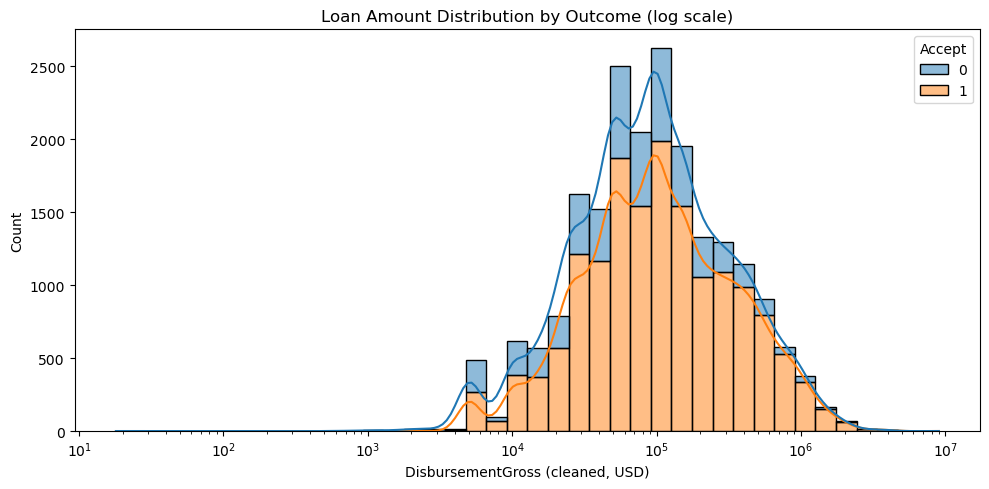

Top loan bands by denial rate:


,loan_band,applications,approval_rate,denial_rate
0,"(17.999, 20000.0]",2322,0.622308,0.377692
1,"(20000.0, 32886.8]",1832,0.740175,0.259825
2,"(50000.0, 66415.6]",1316,0.752280,0.247720
3,"(66415.6, 92964.0]",2077,0.753009,0.246991
4,"(92964.0, 116260.0]",2076,0.757707,0.242293


In [7]:
# Loan Size vs Risk: identify possible "danger zones" by loan amount
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Clean currency strings like "$123,456.00" into numeric values
df['DisbursementGross_cleaned'] = (
    df['DisbursementGross']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace({'': np.nan})
    .astype(float)
)

# Keep only rows with valid loan amount and outcome
plot_df = df.dropna(subset=['DisbursementGross_cleaned', 'Accept']).copy()
plot_df = plot_df[plot_df['DisbursementGross_cleaned'] > 0]

plt.figure(figsize=(10, 5))
sns.histplot(
    data=plot_df,
    x='DisbursementGross_cleaned',
    hue='Accept',
    multiple='stack',
    kde=True,
    log_scale=True,
    bins=40
)
plt.title('Loan Amount Distribution by Outcome (log scale)')
plt.xlabel('DisbursementGross (cleaned, USD)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Optional: quantify denial risk by amount bands
risk_by_band = (
    plot_df.assign(loan_band=pd.qcut(plot_df['DisbursementGross_cleaned'], q=10, duplicates='drop'))
    .groupby('loan_band', observed=False)['Accept']
    .agg(applications='size', approval_rate='mean')
    .assign(denial_rate=lambda x: 1 - x['approval_rate'])
    .sort_values('denial_rate', ascending=False)
    .reset_index()
)

print('Top loan bands by denial rate:')
display(risk_by_band.head(5))

Highest denial band: <br>
[ 18 , 20000] with denial rate ≈ 37.8% 
(approval ≈ 62.2%).<br>
Next highest: 
[20000, 32886.8] with denial rate ≈ 26.0%.<br>
Most other higher bands are around ≈ 24% − 25%.

In [8]:
# Audit DisbursementGross values before filtering with dropna
raw_disb = df['DisbursementGross']
cleaned_str = (
    raw_disb.astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace({'': np.nan, 'nan': np.nan, 'None': np.nan})
)
cleaned_num = pd.to_numeric(cleaned_str, errors='coerce')

audit = pd.DataFrame({
    'DisbursementGross_raw': raw_disb,
    'DisbursementGross_cleaned_str': cleaned_str,
    'DisbursementGross_cleaned_num': cleaned_num,
    'Accept': df['Accept']
})

# Invalid for analysis means missing/non-numeric/non-positive loan amount
invalid_mask = audit['DisbursementGross_cleaned_num'].isna() | (audit['DisbursementGross_cleaned_num'] <= 0)
invalid_rows = audit.loc[invalid_mask].copy()

print(f"Total rows: {len(audit):,}")
print(f"Invalid DisbursementGross rows: {len(invalid_rows):,}")
print(f"Invalid share: {len(invalid_rows) / len(audit):.2%}")

print('\nBreakdown of invalid reasons:')
reason_counts = pd.Series({
    'missing_or_non_numeric': int(audit['DisbursementGross_cleaned_num'].isna().sum()),
    'non_positive_value': int((audit['DisbursementGross_cleaned_num'] <= 0).sum())
})
display(reason_counts.to_frame('count'))

print('\nSample invalid rows (up to 25):')
display(invalid_rows.head(25))

# If you want to inspect all invalid rows, uncomment:
# display(invalid_rows)

Total rows: 20,768
Invalid DisbursementGross rows: 1
Invalid share: 0.00%

Breakdown of invalid reasons:


,count
missing_or_non_numeric,0
non_positive_value,1



Sample invalid rows (up to 25):


,DisbursementGross_raw,DisbursementGross_cleaned_str,DisbursementGross_cleaned_num,Accept
11414,$0.00,0.00,0.0,0
